# M4A5 - Fundamentos de Modelos Multimodais

Na prática de hoje vamos usar o modelo [CLIP](https://openai.com/index/clip/) da OpenAI.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Utilizar o modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
%pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /private/var/folders/6c/2ww5xq0n467gmqjkphdwft5h0000gn/T/pip-req-build-4keqd59s
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /private/var/folders/6c/2ww5xq0n467gmqjkphdwft5h0000gn/T/pip-req-build-4keqd59s
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


Importar as bibliotecas e Ler Imagens do Disco

In [3]:
import torch
import clip
import matplotlib.pyplot as plt
from PIL import Image

## Utilizar o Modelo

Para isso iremos instanciar o modelo do CLIP e utilizar com texto e imagens.

['a cat', 'a dog', 'a diagram']
Probabilidades imagem vs. textos: [0.32% de "a cat", 99.62% de "a dog", 0.09% de "a diagram"]


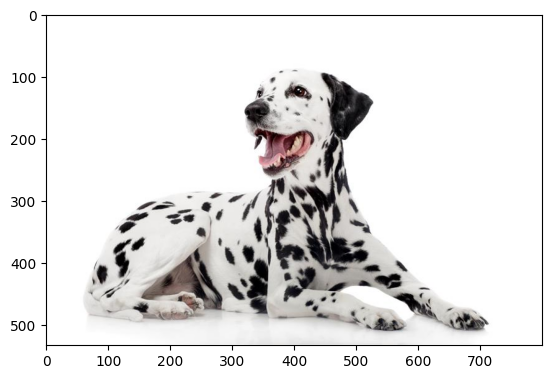

In [4]:
# Path para a imagem.
# path_image = "images/rio.jpeg"
path_image = "images/dog.jpeg"

# Textos para avaliar.
# texts = ["a statue", "the moutains", "the beach"]
texts = ["a cat", "a dog", "a diagram"]

# Define o dispositivo a carregar o modelo.
device = "mps" if torch.mps.is_available() else "cpu"

# Carrega o modelo com o backbone do ViT-B/32.
model, preprocess = clip.load("ViT-B/32", device=device)


# Processa a imagem.
image = preprocess(Image.open(path_image)).unsqueeze(0).to(device)

# Processa o texto.
text = clip.tokenize(texts).to(device)

# Roda inferências.
with torch.no_grad():
    _ = model.encode_image(image) # Encoda imagem.
    _ = model.encode_text(text) # Encoda o texto.
    
    logits_per_image, logits_per_text = model(image, text) # Computa similaridade entre imagem e textos.
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0] # Retorna probabilidades.

formated_probs_str = '[' + ', '.join(f'{x * 100:.2f}% de "{t}"' for x, t in zip(list(probs), texts)) + ']'

plt.imshow(Image.open(path_image))
print(texts)
print("Probabilidades imagem vs. textos:", formated_probs_str)

## Próximos Passos e Referências

Nas próximas práticas vamos trabalhar com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://github.com/openai/CLIP
- https://openai.com/index/clip/
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [ ] Tente utilizar outros dados imagens e textos.
- [ ] Tente utilizar outro modelo base do CLIP. Details on https://github.com/openai/CLIP/blob/main/model-card.md#model-versions .

### Outros modelos com CLIP

In [7]:
clip.available_models()

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

Familia RN50 não funciona com mps (Metal), provavel que precise utilizar cpu ou cuda.

mps
Entrei no no_grad
Entrei no model.encode_image
Entrei no model.encode_text
Entrei na inferencia
['dalmatian', 'husky', 'poodle']
Probabilidades imagem vs. textos: [100.00% de "dalmatian", 0.00% de "husky", 0.00% de "poodle"]


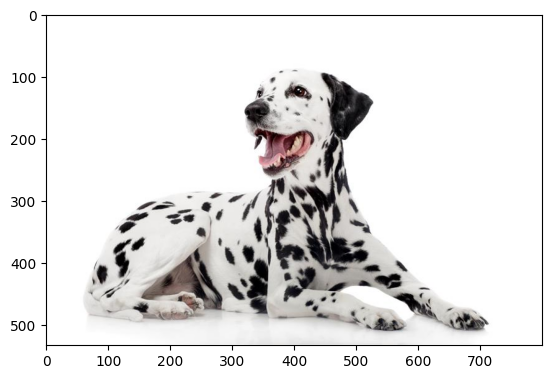

In [6]:
model, preprocess = clip.load("ViT-B/16", device=device)
image = preprocess(Image.open(path_image)).unsqueeze(0).to(device)
texts = ['dalmatian', 'husky', 'poodle']

print(device)
text = clip.tokenize(texts).to(device)

with torch.no_grad():
    print("Entrei no no_grad")
    model.encode_image(image)
    print("Entrei no model.encode_image")
    model.encode_text(text)
    print("Entrei no model.encode_text")
    logits_per_image,logits_per_text = model(image, text)
    print("Entrei na inferencia")
    probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]
    
formated_probs_str = '[' + ', '.join(f'{x * 100:.2f}% de "{t}"' for x, t in zip(list(probs), texts)) + ']'
plt.imshow(Image.open(path_image))
print(texts)
print("Probabilidades imagem vs. textos:", formated_probs_str)